In [18]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from utils import TensorCode_util as tc
import numpy as np
import matplotlib.pyplot as plt
from utils import initvalues_util
import copy
import utils.model_utils as model_utils
from keras.callbacks import EarlyStopping


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
model_type = "DT" # "RF", "ANN"
num_bodies = 2
equal_masses = True

num_pred_steps_to_plot = 125

In [32]:
dataset_sub_name = ""
if equal_masses:
    dataset_sub_name = dataset_sub_name + "_equal_mass"

if equal_masses:
    sub_name = '_equal_masses'
else:
    sub_name = ""
    

In [33]:
tau, n, m, r, v = initvalues_util.initValues(num_bodies=num_bodies, equal_mass=equal_masses)

In [34]:
r_t = [r]
v_t = [v]

for k in range(num_pred_steps_to_plot):
    rv = np.column_stack([r, v])
    
    rv1, kepler_data = tc.do_step_wrapper_normal(tau, n, m, rv, gen_kepler_data=True)
    r1, v1 = np.split(rv1, indices_or_sections=2, axis=-1)
    
    r, v = r1, v1
    r_t.append(r)
    v_t.append(v)

r_t = np.array(r_t)
v_t = np.array(v_t)

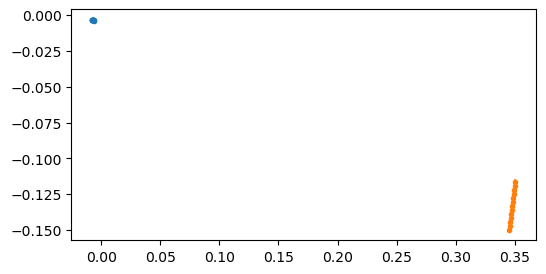

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for i_planet in range(n):
    ax.plot(*r_t[:, i_planet, :2].T, '.-', markevery = 10)

In [36]:
all_kepler_data_1 = np.load(f'datasets/kepler_solver/simulated_train_dataset_2_body{dataset_sub_name}_test.npy')
all_kepler_data_2 = np.load(f'datasets/kepler_solver/simulated_train_dataset_3_body{dataset_sub_name}_test.npy')
all_kepler_data = np.concatenate((all_kepler_data_1, all_kepler_data_2))

In [37]:
x_train, y_train = all_kepler_data[:, :7], all_kepler_data[:, 7:]

# Get trained model

## Decision Trees

In [38]:
if model_type == 'DT':
    model_params = {"max_depth": 40}
    model = model_utils.decision_tree(x_train, y_train, model_params)

## Random Forests

In [39]:
if model_type == 'RF':
    model_params = {"n_estimators": 20, "max_depth": 30}
    model = model_utils.random_forest(x_train, y_train, model_params)

## ANN

In [40]:
if model_type == 'ANN':
    
    early_stopping = EarlyStopping(monitor='loss',  # Monitor validation loss
                                                    patience=10,  # Number of epochs without improvement
                                                    restore_best_weights=True)  # Restore best weights
    
    # optimizer = optimizers.Adam(learning_rate=1e-1)

    model_params = {"epochs": 1000,
                    "optimizer": 'adam',
                    "activation": 'leaky_relu',
                    "input_dims": (7,),
                    "output_dims": 6,
                    "loss_func": 'mean_squared_error',
                    "layer_width": 15,
                    "n_layers": 5,
                    "callbacks": early_stopping,
                    "batch_size": 256}

    model = model_utils.ANN(
        x_train, y_train, model_params)

## Save trained model

In [41]:
# model_utils.save_trained_model(model, model_type, f'trained_models/{model_type}{sub_name}_trained')

# Use the trained Model

In [42]:
tau, n, m, r, v = initvalues_util.initValues(num_bodies=num_bodies, equal_mass=equal_masses)

n = len(m)

r_t_preds = [r]
v_t_preds = [v]
m = np.array(m)
num_of_steps = num_pred_steps_to_plot

for k in range(num_of_steps):
    rv = np.column_stack([r, v])
    
    rv1 = tc.do_step_wrapper_normal(tau, n, m, rv, model = model)[0]
    r1, v1 = np.split(rv1, indices_or_sections=2, axis=-1)

    r_t_preds.append(r1)
    v_t_preds.append(v1)
    r = copy.deepcopy(r1)
    v = copy.deepcopy(v1)
    
r_t_preds = np.stack(r_t_preds)
v_t_preds = np.stack(v_t_preds)

print("r_t.shape", r_t_preds.shape)

r_t.shape (126, 2, 3)


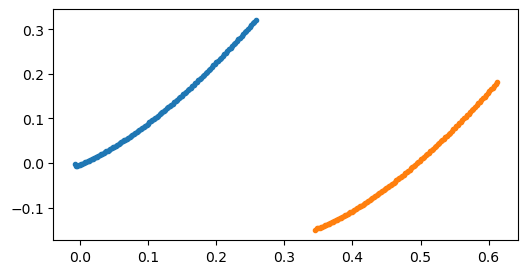

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for i_planet in range(n):
    ax.plot(*r_t_preds[:, i_planet, :2].T, '.-', markevery=1)

In [16]:
# plot.plot_planetary_trajectories(r_t, r_t_preds, "filepath", num_steps=num_of_steps, savefig=False, sub_name=dataset_sub_name)

In [ ]:
# plot.plot_pointwise_mse(r_t, r_t_preds, "", num_steps=10, savefig=False, sub_name=dataset_sub_name)